# Multi-class Classification with Keras

**Unit:** Unit 4: Neural Networks Fundamentals

So far our networks answered yes/no questions: one output neuron, one threshold.
But most real classification problems have **many possible answers** — which digit
is this, which language, which product category? A single output neuron cannot
represent ten alternatives. In this notebook we train a small **multi-layer
perceptron (MLP)** to read handwritten digits (0–9): ten output neurons, a
**softmax** activation that turns scores into class probabilities, and the
**categorical crossentropy** loss that trains against one-hot labels. We then read
the training curves, inspect the confusion matrix and actual mistakes, and finish
comparatively: does adding a second hidden layer help on this dataset?

## 📚 Learning Objectives

By completing this notebook, you will:
- Load and inspect the scikit-learn digits dataset (8×8 images, no download needed)
- One-hot encode labels and pair a softmax output layer with categorical crossentropy
- Train an MLP for classification, reading per-epoch loss and accuracy
- Plot training curves and diagnose the fit
- Build a confusion matrix and inspect misclassified digits
- Compare a 1-hidden-layer vs a 2-hidden-layer MLP with a summary table

---

## 1. The Data: 8×8 Handwritten Digits

scikit-learn ships a small digits dataset — 1,797 grayscale images, each just 8×8
pixels, labeled 0–9. It loads instantly with no download, and it is small enough
that an MLP trains in seconds while still being a genuine 10-class image problem.

We prepare it in three standard steps:
1. **Scale** pixel values from 0–16 down to 0–1 (networks train better on small inputs).
2. **Split** into training and test sets (stratified, so every digit keeps its share).
3. **One-hot encode** the labels: digit `3` becomes `[0,0,0,1,0,0,0,0,0,0]` — the
   10-dimensional target that categorical crossentropy expects.

Dataset      : 1797 images, 64 features (8x8 pixels)
Classes      : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Pixel range  : 0 to 16


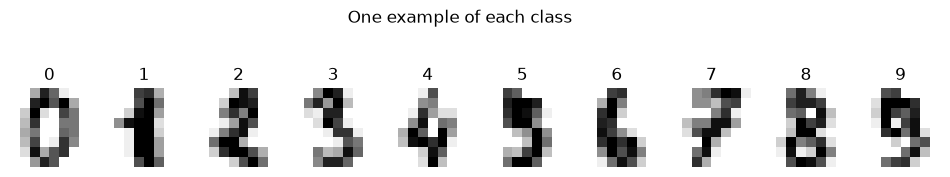


Training set : 1347 images
Test set     : 450 images
Label '2' one-hot encoded -> [0 0 1 0 0 0 0 0 0 0]


In [1]:
# Setup for 10-class digit recognition: load the 8x8 digits, scale pixels to [0,1],
# split stratified, and one-hot encode labels — the standard multiclass pipeline.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import to_categorical

digits = load_digits()
X_raw, y, images = digits.data, digits.target, digits.images

print(f"Dataset      : {X_raw.shape[0]} images, {X_raw.shape[1]} features (8x8 pixels)")
print(f"Classes      : {np.unique(y).tolist()}")
print(f"Pixel range  : {X_raw.min():.0f} to {X_raw.max():.0f}")

# One example of each digit
# Look at the data first: one sample image per class.
fig, axes = plt.subplots(1, 10, figsize=(12, 1.8))
for d, ax in enumerate(axes):
    ax.imshow(images[y == d][0], cmap="gray_r")
    ax.set_title(str(d))
    ax.axis("off")
plt.suptitle("One example of each class", y=1.15)
plt.show()

# Scale, split (stratified), one-hot encode
# Scale, split, and one-hot encode: softmax + categorical crossentropy expect one column per class.
X = X_raw / 16.0
idx_train, idx_test = train_test_split(
    np.arange(len(X)), test_size=450, random_state=42, stratify=y)
X_train, X_test = X[idx_train], X[idx_test]
y_train, y_test = y[idx_train], y[idx_test]
Y_train, Y_test = to_categorical(y_train, 10), to_categorical(y_test, 10)

print(f"\nTraining set : {len(X_train)} images")
print(f"Test set     : {len(X_test)} images")
print(f"Label '{y_train[0]}' one-hot encoded -> {Y_train[0].astype(int)}")

## 2. Baseline: an MLP with One Hidden Layer

The baseline model has three parts:

- `Dense(32, activation="relu")` — a hidden layer of 32 neurons that learns pixel patterns;
- `Dense(10, activation="softmax")` — ten output neurons, one per digit. Softmax
  turns their raw scores into **probabilities that sum to 1**, so the network's
  answer is "how confident am I in each of the ten digits";
- `loss="categorical_crossentropy"` — punishes the model when it puts low
  probability on the true class. Softmax + one-hot labels + categorical
  crossentropy is *the* standard recipe for multi-class classification.

We train for 15 epochs, holding out 15% of the training set for validation, and
print loss/accuracy per epoch.

In [2]:
# Train the baseline MLP: 64 pixels in, softmax over 10 digits out. The epoch table
# shows train AND validation metrics — the pair to watch for overfitting.
EPOCHS = 15

def build_and_train(hidden_layers, tag):
    keras.utils.set_random_seed(42)
    model = Sequential([Input(shape=(64,))]
                       + [Dense(n, activation="relu") for n in hidden_layers]
                       + [Dense(10, activation="softmax")])
    model.compile(optimizer="adam", loss="categorical_crossentropy",
                  metrics=["accuracy"])
    history = model.fit(X_train, Y_train, epochs=EPOCHS, batch_size=32,
                        validation_split=0.15, verbose=0)
    print(f"[{tag}] hidden layers {hidden_layers} -> "
          f"{model.count_params()} trainable parameters")
    return model, history.history

# Train the 1-hidden-layer baseline and print its learning curve as a table.
model1, hist1 = build_and_train([32], "baseline")

print(f"\n{'epoch':>5} | {'loss':>7} | {'acc':>6} | {'val_loss':>8} | {'val_acc':>7}")
print("-" * 46)
for e in range(EPOCHS):
    print(f"{e + 1:>5} | {hist1['loss'][e]:>7.4f} | {hist1['accuracy'][e]:>6.3f} | "
          f"{hist1['val_loss'][e]:>8.4f} | {hist1['val_accuracy'][e]:>7.3f}")

test_loss1, test_acc1 = model1.evaluate(X_test, Y_test, verbose=0)
print(f"\nBaseline test accuracy: {test_acc1:.3f}  (test loss {test_loss1:.4f})")

[baseline] hidden layers [32] -> 2410 trainable parameters

epoch |    loss |    acc | val_loss | val_acc
----------------------------------------------
    1 |  2.2208 |  0.113 |   2.0919 |   0.217
    2 |  1.9381 |  0.428 |   1.7850 |   0.557
    3 |  1.6221 |  0.622 |   1.4518 |   0.685
    4 |  1.3123 |  0.742 |   1.1526 |   0.808
    5 |  1.0482 |  0.837 |   0.9269 |   0.867
    6 |  0.8500 |  0.885 |   0.7611 |   0.892
    7 |  0.7062 |  0.902 |   0.6410 |   0.897
    8 |  0.6007 |  0.914 |   0.5516 |   0.901
    9 |  0.5215 |  0.924 |   0.4830 |   0.921
   10 |  0.4594 |  0.934 |   0.4278 |   0.926
   11 |  0.4102 |  0.935 |   0.3847 |   0.926
   12 |  0.3708 |  0.938 |   0.3502 |   0.931
   13 |  0.3385 |  0.939 |   0.3220 |   0.931
   14 |  0.3117 |  0.941 |   0.2986 |   0.931
   15 |  0.2889 |  0.946 |   0.2792 |   0.931

Baseline test accuracy: 0.933  (test loss 0.2893)


## 3. Training Curves

The per-epoch table is easier to judge as a picture. Two things to check:
does the loss keep falling (still learning?), and does the validation curve track
the training curve (or drift away, which would signal overfitting)?

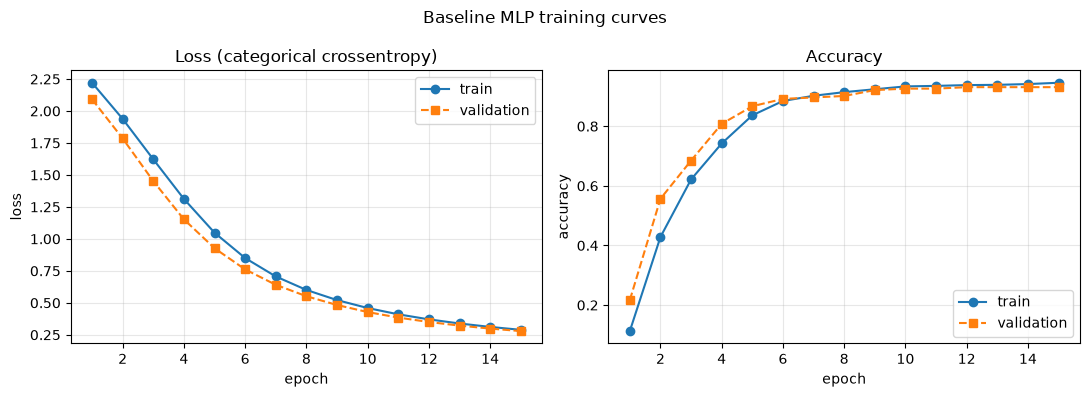

Loss fell from 2.221 (epoch 1) to 0.289 (epoch 15).
Final gap train vs validation accuracy: +0.015


In [3]:
# The same history as pictures: loss and accuracy per epoch for train vs validation.
# Parallel falling curves = healthy; a widening gap = memorization starting.
epochs_range = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(epochs_range, hist1["loss"], "o-", label="train")
ax1.plot(epochs_range, hist1["val_loss"], "s--", label="validation")
ax1.set_title("Loss (categorical crossentropy)")
ax1.set_xlabel("epoch"); ax1.set_ylabel("loss"); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(epochs_range, hist1["accuracy"], "o-", label="train")
ax2.plot(epochs_range, hist1["val_accuracy"], "s--", label="validation")
ax2.set_title("Accuracy")
ax2.set_xlabel("epoch"); ax2.set_ylabel("accuracy"); ax2.legend(); ax2.grid(alpha=0.3)
plt.suptitle("Baseline MLP training curves")
plt.tight_layout()
plt.show()

print(f"Loss fell from {hist1['loss'][0]:.3f} (epoch 1) to {hist1['loss'][-1]:.3f} (epoch {EPOCHS}).")
print(f"Final gap train vs validation accuracy: "
      f"{hist1['accuracy'][-1] - hist1['val_accuracy'][-1]:+.3f}")

## 4. Where Does It Go Wrong? Confusion Matrix and Real Mistakes

Overall accuracy hides *which* digits get confused with which. The confusion
matrix counts every (true digit, predicted digit) pair on the test set — a perfect
model would put all counts on the diagonal. We then look at a few actual
misclassified images to see whether the mistakes are understandable.

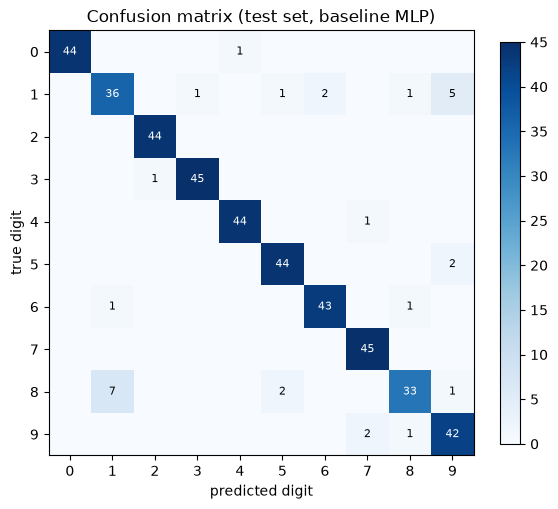

Misclassified: 30 of 450 test images (6.7%)


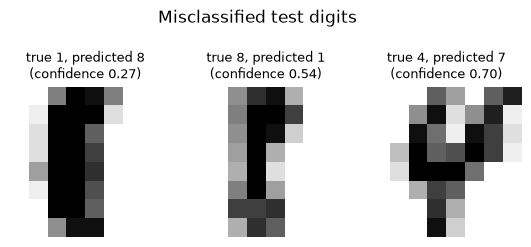

  image #0: true=1  predicted=8  confidence=0.27
  image #25: true=8  predicted=1  confidence=0.54
  image #28: true=4  predicted=7  confidence=0.70


In [4]:
# Beyond a single accuracy number: the confusion matrix shows WHICH digits get mixed
# up, and the misclassified images show WHY — often genuinely ambiguous handwriting.
from sklearn.metrics import confusion_matrix

probs = model1.predict(X_test, verbose=0)
y_pred = probs.argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel("predicted digit"); ax.set_ylabel("true digit")
ax.set_title("Confusion matrix (test set, baseline MLP)")
for i in range(10):
    for j in range(10):
        if cm[i, j] > 0:
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black",
                    fontsize=8)
plt.colorbar(im, shrink=0.8)
plt.tight_layout()
plt.show()

# Inspect a few individual failures; note the model's confidence on each.
wrong = np.where(y_pred != y_test)[0]
print(f"Misclassified: {len(wrong)} of {len(y_test)} test images "
      f"({len(wrong) / len(y_test):.1%})")

show = wrong[:3]
fig, axes = plt.subplots(1, len(show), figsize=(2.2 * len(show), 2.6))
for ax, k in zip(np.atleast_1d(axes), show):
    ax.imshow(images[idx_test[k]], cmap="gray_r")
    ax.set_title(f"true {y_test[k]}, predicted {y_pred[k]}\n"
                 f"(confidence {probs[k].max():.2f})", fontsize=9)
    ax.axis("off")
plt.suptitle("Misclassified test digits", y=1.08)
plt.show()

for k in show:
    print(f"  image #{k}: true={y_test[k]}  predicted={y_pred[k]}  "
          f"confidence={probs[k].max():.2f}")

## 5. Change One Thing: Add a Second Hidden Layer

Would a deeper network do better? We keep everything identical — data, loss,
optimizer, epochs, seed — and change only the architecture: a second hidden layer
of 16 ReLU neurons between the existing hidden layer and the softmax output.
Then we put both models side by side.

In [5]:
# Does a second hidden layer help? Same training budget, one architecture change —
# compare parameters and test accuracy to judge whether the extra depth pays for itself.
model2, hist2 = build_and_train([32, 16], "2-hidden-layer")
test_loss2, test_acc2 = model2.evaluate(X_test, Y_test, verbose=0)

rows = [
    ("1 hidden layer  [32]",      model1, hist1, test_acc1),
    ("2 hidden layers [32, 16]",  model2, hist2, test_acc2),
]
print(f"\n{'model':<26} | {'params':>6} | {'train acc':>9} | {'val acc':>7} | {'test acc':>8}")
print("-" * 70)
for name, model, hist, test_acc in rows:
    print(f"{name:<26} | {model.count_params():>6} | {hist['accuracy'][-1]:>9.3f} | "
          f"{hist['val_accuracy'][-1]:>7.3f} | {test_acc:>8.3f}")

diff = test_acc2 - test_acc1
print(f"\nTest-accuracy difference (2-layer minus 1-layer): {diff:+.3f} "
      f"({abs(diff) * len(y_test):.0f} test images)")

[2-hidden-layer] hidden layers [32, 16] -> 2778 trainable parameters

model                      | params | train acc | val acc | test acc
----------------------------------------------------------------------
1 hidden layer  [32]       |   2410 |     0.946 |   0.931 |    0.933
2 hidden layers [32, 16]   |   2778 |     0.945 |   0.906 |    0.938

Test-accuracy difference (2-layer minus 1-layer): +0.004 (2 test images)


---

## ✅ Summary

**What the outputs actually show:**

- The baseline MLP (one hidden layer, softmax output, categorical crossentropy)
  learns fast: loss falls from 2.22 to 0.29 in 15 epochs and test accuracy reaches
  **0.933** (30 of 450 test images wrong, 6.7%). The loss is still falling at epoch
  15 — we stop early to keep the notebook fast, and a longer budget would keep
  improving the model.
- The training curves show validation tracking training closely (final accuracy
  gap about 1.5 points) — no serious overfitting at this size.
- The confusion matrix is strongly diagonal. The most common mix-up is **1 ↔ 8**,
  and the misclassified images show why: at 8×8 resolution, a thick "1" and a
  narrow "8" are nearly the same blob of pixels.
- Adding a second hidden layer changed test accuracy from 0.933 to 0.938 — a
  difference of just **2 test images** — while validation accuracy came out
  slightly *lower*. At the same training budget, extra depth bought no meaningful
  accuracy on this small, easy dataset: depth is not free accuracy.

**The recipe to remember** for any multi-class problem in Keras:
one output neuron *per class*, `softmax` activation, one-hot labels, and
`categorical_crossentropy` loss.

---

## 📚 References

1. Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). *Learning Representations by Back-Propagating Errors*. Nature, 323, 533–536.
2. Bridle, J. S. (1990). *Probabilistic Interpretation of Feedforward Classification Network Outputs, with Relationships to Statistical Pattern Recognition* (softmax). In Neurocomputing: Algorithms, Architectures and Applications, Springer.
3. Kingma, D. P., & Ba, J. (2015). *Adam: A Method for Stochastic Optimization*. ICLR. <https://arxiv.org/abs/1412.6980>
4. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*, Ch. 6: Deep Feedforward Networks (includes the XOR example). MIT Press.